# Multilevel Modeling Using Bambi

Explored multilevel modeling using Bambi, this notebook is therefore just a test and could be used as inspiration. These functions have therefore not been exported. We have tried using "Gender | Component", which means that we believe that the effect of gender may vary depending on component. We have also tried "Component | Gender", which means that we believe that the effect of component may vary depending on the gender. We tried both since we were unsure of which effect was desired.

In [1]:
import pandas as pd
import bambi as bmb
import arviz as az
import numpy as np
from anthromass.anthro_module import *

az.style.use("arviz-darkgrid")
np.random.default_rng(8924)

Generator(PCG64) at 0x11D61E7A0

Here we used the original data file, where males and females have been combined.

In [2]:
ansur=pd.read_csv('../data/processed/ANSURIImalefemale.csv')

This function allows you to set priors for the model. This change was made to ensure that the prior predictive mean is positive, and thereby giving the model more information. 

In [3]:
def setpriors_com(measurement, data):
    
    mean = data[measurement].mean()
    sd = data[measurement].std()

    mean_weight = data['weightkg'].mean()   
    mean_stature = data['stature'].mean()   

    priors = {
        "Intercept": bmb.Prior("Normal", mu=mean, sigma=sd*3),
        "Gender": bmb.Prior("Normal", mu=0, sigma=1),
        "weightkg": bmb.Prior("Normal", mu=mean/mean_weight, sigma=1),
        "stature": bmb.Prior("Normal", mu=mean/mean_stature, sigma=1),
        "Gender|Component": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("Exponential", lam=1)),
        "sigma": bmb.Prior("Exponential", lam=1),
    }
    return priors
    

The function below creates and build the model. Here the priors that were set in the functions above are called upon. 

In [4]:
def component_model(measurement, formula, data):
    model = bmb.Model(
    formula=f"{measurement} ~" + formula,
    data=data,
    priors=setpriors_com(measurement, data),
    noncentered=True
    )
    model.build()
    return model


The function fits the model which was created by the function above by calling upon that function. 

In [5]:
def fitted_component_model(measurement, formula, data):
    model=component_model(measurement, formula, data)
    fitted_model = model.fit(draws=2000, tune=2000, chains = 4, cores = 1, target_accept=0.95, progressbar=True)

    return fitted_model

## GENDER | COMPONENT

Here the first multilevel function is created using the functions from above. The formula chosen can be seen below, where Gender | Component was used. Here the model is called bambi_ml_gc which stands for bambi_multilevel_gendercomponent. A model is created and fitted for all measurement in variables. 

In [ ]:
variables = measurement_names()
variables = variables[1:2]
kindofmodel = 'bambi_ml_gc'
formula = " 1 + Gender + weightkg + stature + (0 + Gender|Component)"
for var in variables:
    model=component_model(var,formula,ansur)
    fitted_model = fitted_component_model(var, formula, ansur)
    #make_pickle(model, kindofmodel, var)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, Gender, weightkg, stature, Gender|Component_sigma, Gender|Component_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 259 seconds.


This allows us to visualize the prior predictive the model makes. The predictions it makes before seeing the data.

Sampling: [Gender, Gender|Component_offset, Gender|Component_sigma, Intercept, acromialheight, sigma, stature, weightkg]


<Axes: xlabel='acromialheight'>

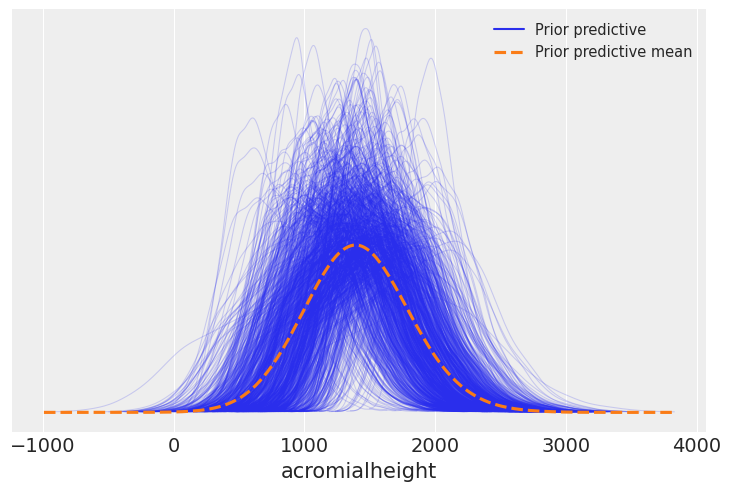

In [7]:
prior_pred = model.prior_predictive(draws=1000)
az.plot_ppc(prior_pred, group="prior")

This allows us to visualize the posterior predictive meaning the predictions the model makes after seeing the data. 

<Axes: xlabel='acromialheight'>

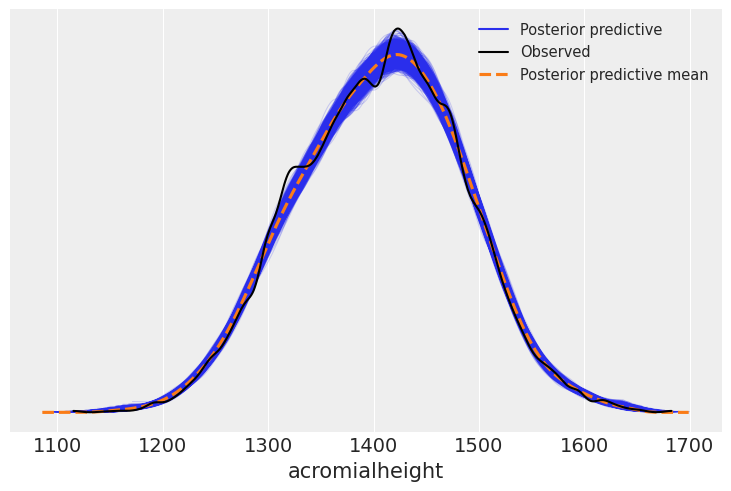

In [8]:
model.predict(fitted_model, kind="response")
az.plot_ppc(fitted_model)

The code cell below allows us to follow the regression process. Here we can see the density plot on the left and the trace lines on the right. All MCMC chains converge to the same distribution which means the regression process was successfull. 

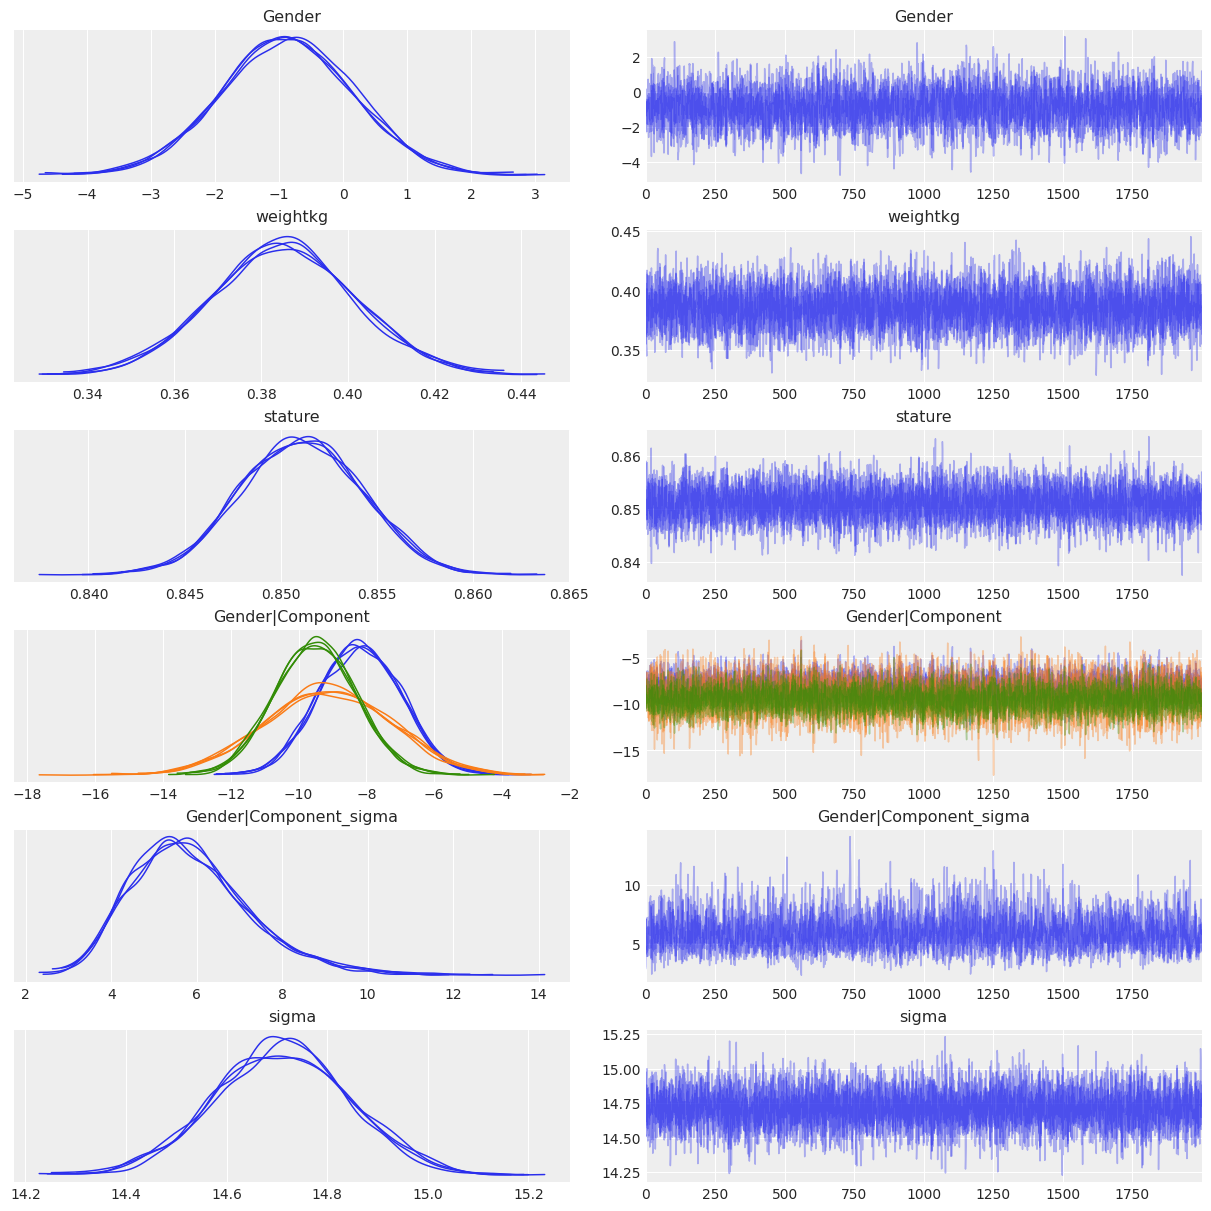

In [9]:
var_names = ["Gender", "weightkg", "stature", "Gender|Component", "Gender|Component_sigma", "sigma"]
az.plot_trace(
    data=fitted_model,
    var_names=var_names, 
    compact=True, 
    chain_prop={"ls": "-"}
);

## COMPONENT | GENDER

Here the second multilevel function is created using the functions from above. The formula chosen can be seen below, where Component | Gender was used. Here the model is called bambi_ml_cg which stands for bambi_multilevel_componentgender. A model is created and fitted for all measurement in variables. (This model sadly takes longer time than the first one and has multiple divergences for each chain. - 2 chains took about 90 minutes for me) 

In [ ]:
variables = measurement_names()
variables = variables[1:2]
kindofmodel = 'bambi_ml_cg'
formula = " 1 + Component + weightkg + stature + (0 + Component|Gender)"
for var in variables:
    model=component_model(var,formula,ansur)
    fitted_model = fitted_component_model(var, formula, ansur)
    #make_pickle(model, kindofmodel, var)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, Component, weightkg, stature, Component|Gender_sigma, Component|Gender_offset]


Output()

This allows us to visualize the prior predictive the model makes. The predictions it makes before seeing the data.

In [ ]:
prior_pred = model.prior_predictive(draws=1000)
az.plot_ppc(prior_pred, group="prior")

This allows us to visualize the posterior predictive meaning the predictions the model makes after seeing the data. 

In [ ]:
model.predict(fitted_model, kind="response")
az.plot_ppc(fitted_model)

The code cell below allows us to follow the regression process. Here we can see the density plot on the left and the trace lines on the right. If all MCMC chains converge to the same distribution, the regression process was successfull. 

In [ ]:
var_names = ["Component", "weightkg", "stature", "Component|Gender", "Component|Gender_sigma", "sigma"]
az.plot_trace(
    data=fitted_model,
    var_names=var_names, 
    compact=True, 
    chain_prop={"ls": "-"}
);